### **Name : Vishesh Kumar**  
### **CU24250050**  
### **Sec: B**  
### **Roll No : 69**  
### **Computer Vision**  
### **Labsheet - 5**

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

Image loaded successfully


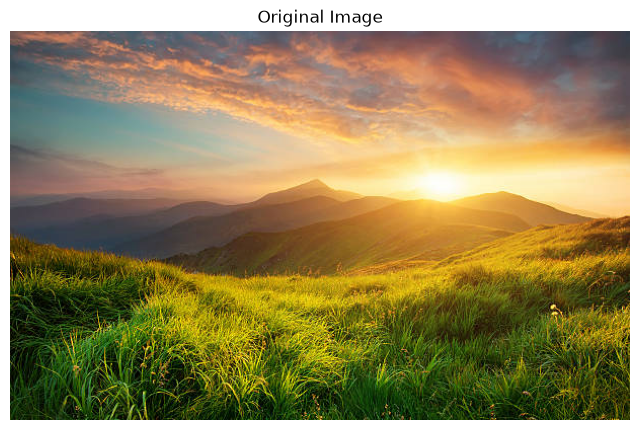

In [41]:
image_path = "sun.jpg"

image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found. Check the image path.")
else:
    print("Image loaded successfully")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

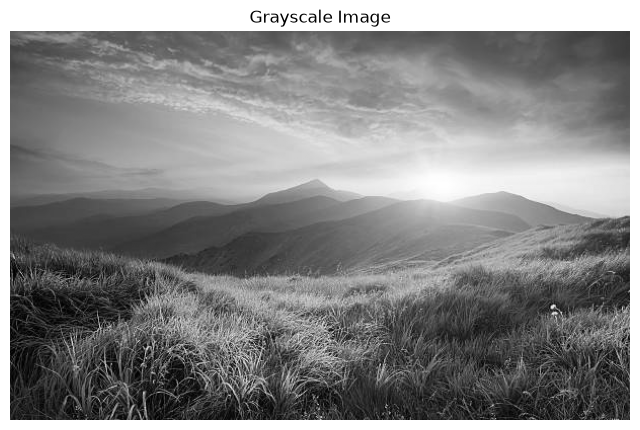

In [42]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [43]:
# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Number of Keypoints:", len(keypoints))
print("Descriptor Shape:", descriptors.shape)

Number of Keypoints: 904
Descriptor Shape: (904, 128)


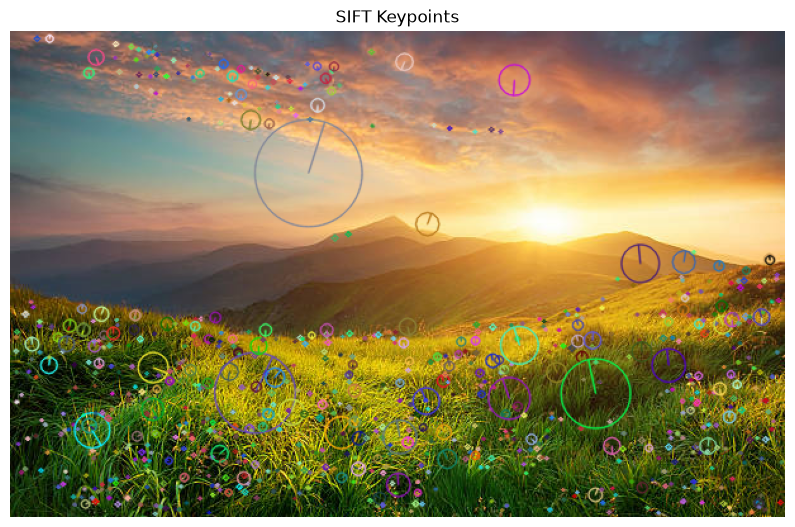

In [44]:
sift_image = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 7))
plt.imshow(sift_image)
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

In [45]:
# Resize image for HOG
hog_image = cv2.resize(gray, (128, 128))

# Extract HOG features
features, hog_visualization = hog(
    hog_image,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

print("Number of HOG Features:", len(features))

Number of HOG Features: 8100


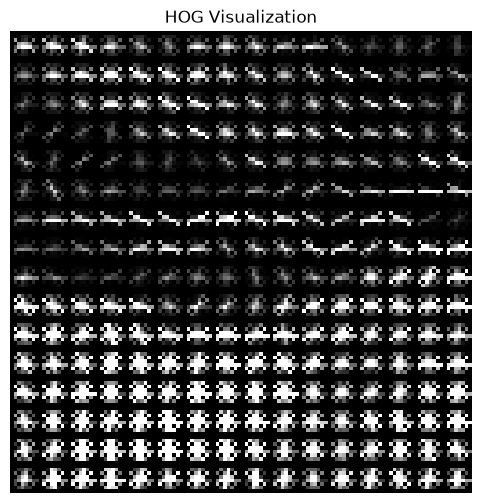

In [46]:
# Improve HOG visualization
hog_visualization = exposure.rescale_intensity(
    hog_visualization,
    in_range=(0, 10)
)

plt.figure(figsize=(8, 6))
plt.imshow(hog_visualization, cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")
plt.show()

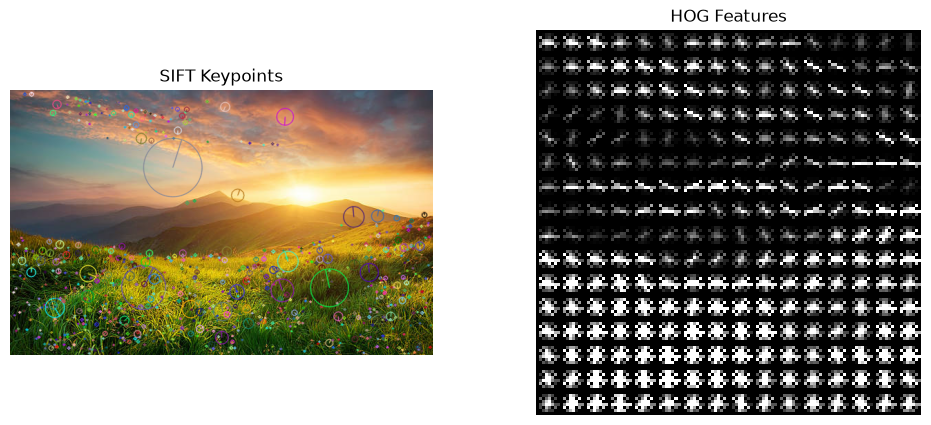

In [47]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sift_image)
plt.title("SIFT Keypoints")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_visualization, cmap="gray")
plt.title("HOG Features")
plt.axis("off")

plt.show()

In [48]:
print("SIFT vs HOG Comparison")
print("-" * 40)

print("SIFT:")
print("1. Detects distinctive keypoints.")
print("2. Strong scale invariance.")
print("3. Strong rotation invariance.")
print("4. Useful for image matching and object recognition.")

print("\nHOG:")
print("1. Represents local gradient orientations.")
print("2. Mainly captures shape and edge information.")
print("3. Computationally simpler than SIFT in many applications.")
print("4. Commonly useful for object detection.")

SIFT vs HOG Comparison
----------------------------------------
SIFT:
1. Detects distinctive keypoints.
2. Strong scale invariance.
3. Strong rotation invariance.
4. Useful for image matching and object recognition.

HOG:
1. Represents local gradient orientations.
2. Mainly captures shape and edge information.
3. Computationally simpler than SIFT in many applications.
4. Commonly useful for object detection.


In [49]:
img1 = cv2.imread("sun.jpg", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Error: Image not found.")
else:
    # Create a second image by slightly rotating the original
    h, w = img1.shape
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, 10, 1.0)
    img2 = cv2.warpAffine(img1, matrix, (w, h))

    print("Both images created successfully")

Both images created successfully


In [50]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print("Image 1 Keypoints:", len(kp1))
print("Image 2 Keypoints:", len(kp2))

Image 1 Keypoints: 879
Image 2 Keypoints: 1060


In [51]:
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Total Matches:", len(matches))
print("Good Matches:", len(good_matches))

Total Matches: 879
Good Matches: 521


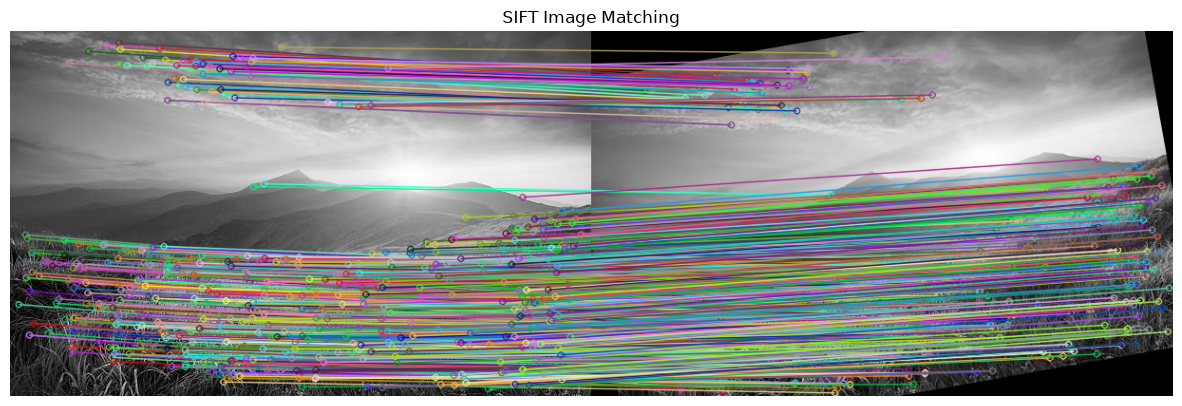

In [52]:
matched_image = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 8))
plt.imshow(matched_image, cmap="gray")
plt.title("SIFT Image Matching")
plt.axis("off")
plt.show()

In [53]:
print("OBSERVATION")
print("-" * 50)

print("SIFT detects distinctive keypoints and generates descriptors")
print("that are robust to scale and rotation changes.")

print("\nHOG represents an image using gradient orientation and")
print("is particularly useful for describing object shape and edges.")

print("\nSIFT is suitable for image matching, object recognition,")
print("and feature correspondence.")

print("\nHOG is commonly suitable for object detection and")
print("shape-based image analysis.")

OBSERVATION
--------------------------------------------------
SIFT detects distinctive keypoints and generates descriptors
that are robust to scale and rotation changes.

HOG represents an image using gradient orientation and
is particularly useful for describing object shape and edges.

SIFT is suitable for image matching, object recognition,
and feature correspondence.

HOG is commonly suitable for object detection and
shape-based image analysis.
